# 04 Train GAN Make Images DIBaS

This notebook trains one StyleGAN2-ADA model per training fold, selects the lowest-KID snapshot in each fold, and generates the exact minority top-up needed for the GAN-balanced CNN runs.


## Important Notes

- Open Jupyter from `x64 Native Tools Command Prompt for VS 2022`.
- Run the notebook itself in the main `fyp2` kernel so the normal notebook packages stay available.
- Keep the `fyp2_stylegan2ada` environment available on the school Windows PC.
- This notebook launches StyleGAN with the dedicated Windows Python path set in the config cell below.
- This notebook keeps the GAN native resolution at `256x256`.
- Every generated image is resized deterministically to `224x224` before the CNN notebooks use it.


In [1]:
from pathlib import Path
import csv
import json
import math
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt

import pandas as pd

from IPython.display import display
from PIL import Image

# This helper keeps the notebook easy to run from the repo root or from notebooks/.
def find_repo_root(start_path: Path) -> Path:
    if (start_path / "raw_data").exists():
        return start_path
    if start_path.name == "notebooks" and (start_path.parent / "raw_data").exists():
        return start_path.parent
    raise FileNotFoundError("Could not find the FYP2 repo root.")

REPO_ROOT = find_repo_root(Path.cwd())
MANIFESTS_DIR = REPO_ROOT / "manifests"
RESULTS_DIR = REPO_ROOT / "results"
CHECKPOINTS_DIR = REPO_ROOT / "checkpoints"
GAN_PATCHES_DIR = REPO_ROOT / "gan_patches_256" / "dibas"
GAN_IMAGES_256_DIR = REPO_ROOT / "gan_images_256" / "dibas"
GAN_IMAGES_224_DIR = REPO_ROOT / "gan_images_224" / "dibas"
THIRD_PARTY_DIR = REPO_ROOT / "third_party"
STYLEGAN_DIR = THIRD_PARTY_DIR / "stylegan2-ada-pytorch"
NOTEBOOK_TAG = "04_train_gan_make_images_dibas"
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
NOTEBOOK_CHECKPOINTS_DIR = CHECKPOINTS_DIR / NOTEBOOK_TAG
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
GAN_IMAGES_256_DIR.mkdir(parents=True, exist_ok=True)
GAN_IMAGES_224_DIR.mkdir(parents=True, exist_ok=True)

SEED = 2026
FOLDS_TO_RUN = [1, 2, 3, 4, 5]
GAN_PATCH_SIZE = 256
CNN_PATCH_SIZE = 224
GAN_BATCH_SIZE = 8
GAN_WORKERS = 3
GAN_KIMG = 200
SNAP_TICKS = 2
GAN_MIRROR = True
ADA_TARGET = 0.6
GAN_CFG = "auto"
GAN_AUG = "ada"
GAN_AUGPIPE = "color"
KID_METRIC_NAME = "kid50k_full"
GENERATE_START_SEED = 10000
GENERATE_NOISE_MODE = "random"
LONG_COMMAND_NOTEBOOK_MODE = "smart"
KID_OPENMP_DUPLICATE_OK = True
STYLEGAN_WINDOWS_PYTHON = Path(r"C:\Users\FYP2610\anaconda3\envs\fyp2_stylegan2ada\python.exe")
STYLEGAN_TORCH_CUDA_ARCH_LIST = "8.0+PTX"
STYLEGAN_EXTENSIONS_DIR = CHECKPOINTS_DIR / "torch_extensions_sm80ptx"
STYLEGAN_EXTENSIONS_DIR.mkdir(parents=True, exist_ok=True)

if os.name == "nt":
    PYTHON_EXE = STYLEGAN_WINDOWS_PYTHON
    if not PYTHON_EXE.exists():
        raise FileNotFoundError(
            f"Could not find the StyleGAN Python executable on the Windows machine: {PYTHON_EXE}"
        )
    STYLEGAN_ENV_ROOT = PYTHON_EXE.parent
    CONDA_EXE = STYLEGAN_ENV_ROOT.parent.parent / "Scripts" / "conda.exe"
    if not CONDA_EXE.exists():
        raise FileNotFoundError(
            f"Could not find conda.exe on the Windows machine: {CONDA_EXE}"
        )
else:
    PYTHON_EXE = Path(sys.executable)
    STYLEGAN_ENV_ROOT = None
    CONDA_EXE = None

STYLEGAN_EXTRA_ENV = {
    "TORCH_CUDA_ARCH_LIST": STYLEGAN_TORCH_CUDA_ARCH_LIST,
    "TORCH_EXTENSIONS_DIR": str(STYLEGAN_EXTENSIONS_DIR),
}
if KID_OPENMP_DUPLICATE_OK:
    STYLEGAN_EXTRA_ENV["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# This helper ensures Windows subprocesses really run inside the StyleGAN conda env.
def build_stylegan_command(script_name: str, *script_args: str):
    if os.name == "nt":
        return [
            str(CONDA_EXE),
            "run",
            "--no-capture-output",
            "-p",
            str(STYLEGAN_ENV_ROOT),
            "python",
            script_name,
            *script_args,
        ]
    return [str(PYTHON_EXE), script_name, *script_args]

In [2]:
# This helper reads a CSV file into a plain list of rows.
def read_csv_rows(csv_path: Path):
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

# This helper writes a CSV file with a stable header.
def write_csv_rows(csv_path: Path, rows, fieldnames):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# This helper writes one small JSON file with clean formatting.
def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

# This helper stores paths in repo-relative form so the outputs stay portable.
def as_repo_relative(repo_root: Path, path_value: Path) -> str:
    return path_value.relative_to(repo_root).as_posix()

# This helper decides which command lines matter enough to echo in the notebook.
def should_echo_command_line(line_text: str, line_index: int, notebook_mode: str) -> bool:
    if notebook_mode == "all":
        return True
    if notebook_mode == "quiet":
        return False
    if line_index <= 20:
        return True
    lowered = line_text.lower()
    important_markers = [
        "training for",
        "tick ",
        "sec/kimg",
        "snapshot",
        "saved",
        "kid50k_full",
        "generating image for seed",
        "traceback",
        "runtimeerror",
        "error:",
    ]
    return any(marker in lowered for marker in important_markers)

# This helper runs a subprocess, streams useful lines to the notebook, and saves a log to disk.
def run_command(command_parts, workdir: Path, live_log_path: Path, notebook_mode: str = "smart", extra_env=None):
    live_log_path.parent.mkdir(parents=True, exist_ok=True)
    command_env = os.environ.copy()
    if extra_env is not None:
        command_env.update(extra_env)

    process = subprocess.Popen(
        command_parts,
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=command_env,
    )

    start_time = time.time()
    output_tail = []
    printed_line_count = 0
    suppressed_line_count = 0
    total_line_count = 0

    with live_log_path.open("w", encoding="utf-8") as log_handle:
        for line in process.stdout:
            total_line_count += 1
            output_tail.append(line)
            output_tail = output_tail[-200:]
            log_handle.write(line)
            log_handle.flush()

            line_text = line.rstrip()
            if should_echo_command_line(line_text, total_line_count, notebook_mode):
                print(line_text)
                printed_line_count += 1
            else:
                suppressed_line_count += 1

    returncode = process.wait()
    duration_seconds = round(time.time() - start_time, 2)
    report = {
        "command": " ".join(str(item) for item in command_parts),
        "returncode": returncode,
        "duration_seconds": duration_seconds,
        "printed_line_count": printed_line_count,
        "suppressed_line_count": suppressed_line_count,
        "total_line_count": total_line_count,
        "log_path": as_repo_relative(REPO_ROOT, live_log_path),
        "output_tail": "".join(output_tail),
    }
    return report

In [3]:
# We load the real patch manifest and compute the exact top-up target for each training fold.
real_patch_rows = read_csv_rows(MANIFESTS_DIR / "patch_manifest_224.csv")
gan_source_rows = read_csv_rows(MANIFESTS_DIR / "gan_patch_manifest_256.csv")
fold_manifest_rows = read_csv_rows(MANIFESTS_DIR / "fold_manifest.csv")

for row in real_patch_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])
for row in gan_source_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])
for row in fold_manifest_rows:
    row["fold_id"] = int(row["fold_id"])
    row["binary_label"] = int(row["binary_label"])

fold_plan_rows = []
for fold_id in FOLDS_TO_RUN:
    train_rows = [row for row in real_patch_rows if int(row["fold_id"]) == fold_id]
    gan_rows = [row for row in gan_source_rows if int(row["fold_id"]) == fold_id]
    train_cocci_count = sum(1 for row in train_rows if int(row["binary_label"]) == 0)
    train_bacilli_count = sum(1 for row in train_rows if int(row["binary_label"]) == 1)
    test_fold_ids = [value for value in FOLDS_TO_RUN if value != fold_id]
    test_fold_text = ",".join(str(value) for value in test_fold_ids)
    if train_cocci_count >= train_bacilli_count:
        raise AssertionError(
            f"Fold {fold_id} no longer has cocci as the minority class. "
            f"cocci={train_cocci_count}, bacilli={train_bacilli_count}"
        )
    needed_gan_count_224 = train_bacilli_count - train_cocci_count
    fold_plan_rows.append({
        "round_id": fold_id,
        "train_fold_id": fold_id,
        "test_fold_ids": test_fold_text,
        "real_train_patch_count_224": len(train_rows),
        "real_cocci_count_224": train_cocci_count,
        "real_bacilli_count_224": train_bacilli_count,
        "needed_gan_count_224": needed_gan_count_224,
        "real_cocci_patch_count_256_for_gan": len(gan_rows),
        "train_raw_sample_count": sum(1 for row in fold_manifest_rows if int(row["fold_id"]) == fold_id),
        "dataset_zip_path": as_repo_relative(REPO_ROOT, NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}" / f"fold_{fold_id}_minority_256.zip"),
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "fold_plan.csv", fold_plan_rows, list(fold_plan_rows[0].keys()))
display(pd.DataFrame(fold_plan_rows))

,round_id,train_fold_id,test_fold_ids,real_train_patch_count_224,real_cocci_count_224,real_bacilli_count_224,needed_gan_count_224,real_cocci_patch_count_256_for_gan,train_raw_sample_count,dataset_zip_path
0,1,1,"2,3,4,5",1566,648,918,270,480,29,results/04_train_gan_make_images_dibas/fold_1/...
1,2,2,"1,3,4,5",1566,648,918,270,480,29,results/04_train_gan_make_images_dibas/fold_2/...
2,3,3,"1,2,4,5",1566,648,918,270,480,29,results/04_train_gan_make_images_dibas/fold_3/...
3,4,4,"1,2,3,5",1566,648,918,270,480,29,results/04_train_gan_make_images_dibas/fold_4/...
4,5,5,"1,2,3,4",1566,648,918,270,480,29,results/04_train_gan_make_images_dibas/fold_5/...


In [4]:
# We create one StyleGAN zip file per training fold so each GAN only sees same-fold minority data.
dataset_zip_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    source_dir = GAN_PATCHES_DIR / f"fold_{fold_id}"
    if not source_dir.exists():
        raise FileNotFoundError(f"Missing GAN source folder for fold {fold_id}: {source_dir}")

    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"
    fold_result_dir.mkdir(parents=True, exist_ok=True)
    dataset_zip_path = REPO_ROOT / fold_plan["dataset_zip_path"]
    if dataset_zip_path.exists():
        dataset_zip_path.unlink()

    dataset_tool_log_path = fold_result_dir / "dataset_tool.log"
    report = run_command(
        build_stylegan_command(
            "dataset_tool.py",
            f"--source={source_dir}",
            f"--dest={dataset_zip_path}",
        ),
        STYLEGAN_DIR,
        live_log_path=dataset_tool_log_path,
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=STYLEGAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "dataset_tool_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"dataset_tool.py failed for fold {fold_id}")

    dataset_zip_rows.append({
        "fold_id": fold_id,
        "source_dir": as_repo_relative(REPO_ROOT, source_dir),
        "dataset_zip_path": as_repo_relative(REPO_ROOT, dataset_zip_path),
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "dataset_zip_manifest.csv", dataset_zip_rows, list(dataset_zip_rows[0].keys()))
display(pd.DataFrame(dataset_zip_rows))

dataset_tool.py:205: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  resample = { 'box': PIL.Image.BOX, 'lanczos': PIL.Image.LANCZOS }[resize_filter]
dataset_tool.py:205: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  resample = { 'box': PIL.Image.BOX, 'lanczos': PIL.Image.LANCZOS }[resize_filter]

 74%|███████▎  | 353/480 [00:01<00:00, 250.42it/s]
dataset_tool.py:205: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  resample = { 'box': PIL.Image.BOX, 'lanczos': PIL.Image.LANCZOS }[resize_filter]
dataset_tool.py:205: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  resample = { 'box': PIL.Image.BOX, 'lanczos': PIL.Image.LANCZOS }[resize_filter]

 73%|███████▎  | 352/480 [00:01<00:00, 252.75it/s]
dataset_tool

,fold_id,source_dir,dataset_zip_path
0,1,gan_patches_256/dibas/fold_1,results/04_train_gan_make_images_dibas/fold_1/...
1,2,gan_patches_256/dibas/fold_2,results/04_train_gan_make_images_dibas/fold_2/...
2,3,gan_patches_256/dibas/fold_3,results/04_train_gan_make_images_dibas/fold_3/...
3,4,gan_patches_256/dibas/fold_4,results/04_train_gan_make_images_dibas/fold_4/...
4,5,gan_patches_256/dibas/fold_5,results/04_train_gan_make_images_dibas/fold_5/...


In [5]:
# We train one StyleGAN2-ADA run per training fold and keep the logs on disk.
training_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    dataset_zip_path = REPO_ROOT / fold_plan["dataset_zip_path"]
    run_parent = NOTEBOOK_CHECKPOINTS_DIR / f"fold_{fold_id}"
    run_parent.mkdir(parents=True, exist_ok=True)
    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"
    train_log_path = fold_result_dir / "train.log"

    report = run_command(
        build_stylegan_command(
            "train.py",
            f"--outdir={run_parent}",
            "--gpus=1",
            f"--data={dataset_zip_path}",
            f"--cfg={GAN_CFG}",
            f"--aug={GAN_AUG}",
            f"--augpipe={GAN_AUGPIPE}",
            f"--mirror={int(GAN_MIRROR)}",
            f"--batch={GAN_BATCH_SIZE}",
            f"--kimg={GAN_KIMG}",
            f"--snap={SNAP_TICKS}",
            f"--workers={GAN_WORKERS}",
            f"--target={ADA_TARGET}",
            f"--metrics={KID_METRIC_NAME}",
        ),
        STYLEGAN_DIR,
        live_log_path=train_log_path,
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=STYLEGAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "train_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"StyleGAN training failed for fold {fold_id}")

    run_dirs = [path for path in run_parent.iterdir() if path.is_dir()]
    if not run_dirs:
        raise FileNotFoundError(f"No StyleGAN run directory was found for fold {fold_id}")
    run_dir = sorted(run_dirs, key=lambda item: item.name)[-1]
    snapshot_paths = sorted(run_dir.glob("network-snapshot-*.pkl"))
    if not snapshot_paths:
        raise FileNotFoundError(f"No snapshots were saved for fold {fold_id}")

    training_rows.append({
        "fold_id": fold_id,
        "run_dir": as_repo_relative(REPO_ROOT, run_dir),
        "latest_snapshot_path": as_repo_relative(REPO_ROOT, snapshot_paths[-1]),
        "train_duration_seconds": report["duration_seconds"],
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "training_run_manifest.csv", training_rows, list(training_rows[0].keys()))
display(pd.DataFrame(training_rows))


Training options:
{
  "num_gpus": 1,
  "image_snapshot_ticks": 2,
  "network_snapshot_ticks": 2,
  "metrics": [
    "kid50k_full"
  ],
  "random_seed": 0,
  "training_set_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "C:\\Users\\FYP2610\\Downloads\\FYP2\\results\\04_train_gan_make_images_dibas\\fold_1\\fold_1_minority_256.zip",
    "use_labels": false,
    "max_size": 480,
    "xflip": true,
    "resolution": 256
  },
  "data_loader_kwargs": {
    "pin_memory": true,
Training for 200 kimg...
tick 0     kimg 0.0      time 1m 05s       sec/tick 4.6     sec/kimg 572.92  maintenance 60.5   cpumem 3.67   gpumem 4.93   augment 0.000
{"results": {"kid50k_full": 0.4596406596134889}, "metric": "kid50k_full", "total_time": 486.7035069465637, "total_time_str": "8m 07s", "num_gpus": 1, "snapshot_pkl": "network-snapshot-000000.pkl", "timestamp": 1776936778.79853}
tick 1     kimg 4.0      time 13m 38s      sec/tick 250.8   sec/kimg 62.70   maintenance 501.6  cpumem

,fold_id,run_dir,latest_snapshot_path,train_duration_seconds
0,1,checkpoints/04_train_gan_make_images_dibas/fol...,checkpoints/04_train_gan_make_images_dibas/fol...,25736.65
1,2,checkpoints/04_train_gan_make_images_dibas/fol...,checkpoints/04_train_gan_make_images_dibas/fol...,25703.38
2,3,checkpoints/04_train_gan_make_images_dibas/fol...,checkpoints/04_train_gan_make_images_dibas/fol...,25588.25
3,4,checkpoints/04_train_gan_make_images_dibas/fol...,checkpoints/04_train_gan_make_images_dibas/fol...,25711.29
4,5,checkpoints/04_train_gan_make_images_dibas/fol...,checkpoints/04_train_gan_make_images_dibas/fol...,25650.56


,fold_id,snapshot_path,snapshot_kimg,kid50k_full
0,1,checkpoints/04_train_gan_make_images_dibas/fol...,8,0.607798
1,1,checkpoints/04_train_gan_make_images_dibas/fol...,16,0.425136
2,1,checkpoints/04_train_gan_make_images_dibas/fol...,24,0.454258
3,1,checkpoints/04_train_gan_make_images_dibas/fol...,32,0.403406
4,1,checkpoints/04_train_gan_make_images_dibas/fol...,40,0.383309
...,...,...,...,...
120,5,checkpoints/04_train_gan_make_images_dibas/fol...,168,0.050456
121,5,checkpoints/04_train_gan_make_images_dibas/fol...,176,0.054765
122,5,checkpoints/04_train_gan_make_images_dibas/fol...,184,0.068396
123,5,checkpoints/04_train_gan_make_images_dibas/fol...,192,0.046019


,fold_id,snapshot_path,snapshot_kimg,kid50k_full
0,1,checkpoints/04_train_gan_make_images_dibas/fol...,184,0.044760
1,2,checkpoints/04_train_gan_make_images_dibas/fol...,192,0.071032
2,3,checkpoints/04_train_gan_make_images_dibas/fol...,184,0.027735
3,4,checkpoints/04_train_gan_make_images_dibas/fol...,168,0.052823
4,5,checkpoints/04_train_gan_make_images_dibas/fol...,200,0.035033


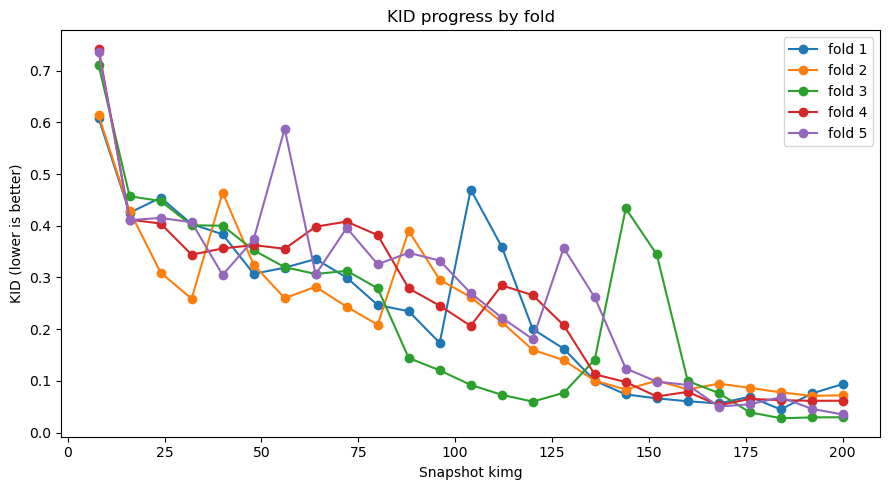

In [6]:
# We read the online KID results from training and select the lowest-KID snapshot per fold.
kid_snapshot_rows = []
kid_rows = []
training_lookup = {int(row["fold_id"]): row for row in training_rows}

def parse_snapshot_kimg(snapshot_path: Path) -> int:
    return int(snapshot_path.stem.replace("network-snapshot-", ""))

def read_kid_values_by_snapshot(run_dir: Path):
    metric_file = run_dir / f"metric-{KID_METRIC_NAME}.jsonl"
    if not metric_file.exists():
        raise FileNotFoundError(f"Missing metric log: {metric_file}")

    kid_values = {}
    lines = [line for line in metric_file.read_text(encoding="utf-8").splitlines() if line.strip()]
    for line in lines:
        record = json.loads(line)
        if "results" not in record or "snapshot_pkl" not in record:
            continue
        kid_value = record["results"].get(KID_METRIC_NAME)
        if kid_value is None:
            continue
        kid_values[record["snapshot_pkl"]] = kid_value
    return kid_values

for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    run_dir = REPO_ROOT / training_lookup[fold_id]["run_dir"]
    snapshot_paths = [path for path in sorted(run_dir.glob("network-snapshot-*.pkl")) if parse_snapshot_kimg(path) > 0]
    if not snapshot_paths:
        raise FileNotFoundError(f"No trained snapshots were found for fold {fold_id}")
    kid_values = read_kid_values_by_snapshot(run_dir)

    fold_snapshot_rows = []
    for snapshot_path in snapshot_paths:
        kid_value = kid_values.get(snapshot_path.name)
        if kid_value is None:
            raise ValueError(
                f"No online KID value was found for fold {fold_id} at {snapshot_path.name}"
            )

        fold_snapshot_rows.append({
            "fold_id": fold_id,
            "snapshot_path": as_repo_relative(REPO_ROOT, snapshot_path),
            "snapshot_kimg": parse_snapshot_kimg(snapshot_path),
            "kid50k_full": kid_value,
        })

    kid_snapshot_rows.extend(fold_snapshot_rows)
    best_row = sorted(fold_snapshot_rows, key=lambda row: (row["kid50k_full"], row["snapshot_kimg"]))[0]
    kid_rows.append(best_row)

write_csv_rows(NOTEBOOK_RESULTS_DIR / "kid_snapshot_results.csv", kid_snapshot_rows, list(kid_snapshot_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "kid_results.csv", kid_rows, list(kid_rows[0].keys()))
kid_snapshot_df = pd.DataFrame(kid_snapshot_rows)
kid_df = pd.DataFrame(kid_rows)
display(kid_snapshot_df)
display(kid_df)

# This figure shows how KID moved across saved snapshots inside each fold.
fig, axis = plt.subplots(figsize=(9, 5))
for fold_id in sorted(kid_snapshot_df["fold_id"].unique()):
    current = kid_snapshot_df[kid_snapshot_df["fold_id"] == fold_id].sort_values("snapshot_kimg")
    axis.plot(current["snapshot_kimg"], current["kid50k_full"], marker="o", label=f"fold {fold_id}")
axis.set_xlabel("Snapshot kimg")
axis.set_ylabel("KID (lower is better)")
axis.set_title("KID progress by fold")
axis.legend()
fig.tight_layout()
fig.savefig(NOTEBOOK_RESULTS_DIR / "kid_progress_by_fold.png", dpi=200)
plt.show()

In [7]:
# We generate exactly the number of synthetic minority images needed to balance each training fold.
kid_lookup = {int(row["fold_id"]): row for row in kid_rows}
generated_rows_256 = []

for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    snapshot_path = REPO_ROOT / kid_lookup[fold_id]["snapshot_path"]
    generated_256_dir = GAN_IMAGES_256_DIR / f"fold_{fold_id}"
    if generated_256_dir.exists():
        shutil.rmtree(generated_256_dir)
    generated_256_dir.mkdir(parents=True, exist_ok=True)

    needed_count = int(fold_plan["needed_gan_count_224"])
    start_seed = GENERATE_START_SEED + (fold_id * 10000)
    end_seed = start_seed + needed_count - 1
    seed_text = f"{start_seed}-{end_seed}"
    fold_result_dir = NOTEBOOK_RESULTS_DIR / f"fold_{fold_id}"
    generate_log_path = fold_result_dir / "generate.log"

    report = run_command(
        build_stylegan_command(
            "generate.py",
            f"--network={snapshot_path}",
            f"--outdir={generated_256_dir}",
            f"--seeds={seed_text}",
            f"--noise-mode={GENERATE_NOISE_MODE}",
            "--trunc=1",
        ),
        STYLEGAN_DIR,
        live_log_path=generate_log_path,
        notebook_mode=LONG_COMMAND_NOTEBOOK_MODE,
        extra_env=STYLEGAN_EXTRA_ENV,
    )
    write_json(fold_result_dir / "generate_report.json", report)
    if report["returncode"] != 0:
        raise RuntimeError(f"StyleGAN generation failed for fold {fold_id}")

    generated_files = sorted(generated_256_dir.glob("seed*.png"))
    if len(generated_files) != needed_count:
        raise AssertionError(
            f"Fold {fold_id} should have {needed_count} generated 256 images, but found {len(generated_files)}."
        )

    for generated_file in generated_files:
        seed_value = int(generated_file.stem.replace("seed", ""))
        test_fold_ids = [value for value in FOLDS_TO_RUN if value != fold_id]
        test_fold_text = ",".join(str(value) for value in test_fold_ids)
        generated_rows_256.append({
            "dataset_name": "dibas",
            "gan_image_id": f"fold{fold_id}_seed{seed_value}_256",
            "fold_id": fold_id,
            "round_id": fold_id,
            "train_fold_id": fold_id,
            "test_fold_ids": test_fold_text,
            "binary_label": 0,
            "binary_group": "cocci",
            "seed": seed_value,
            "image_size": GAN_PATCH_SIZE,
            "file_path": as_repo_relative(REPO_ROOT, generated_file),
            "snapshot_path": as_repo_relative(REPO_ROOT, snapshot_path),
            "source_type": "gan_generated",
        })

write_csv_rows(MANIFESTS_DIR / "gan_generated_manifest_256.csv", generated_rows_256, list(generated_rows_256[0].keys()))
display(pd.DataFrame(generated_rows_256[:10]))

Loading networks from "C:\Users\FYP2610\Downloads\FYP2\checkpoints\04_train_gan_make_images_dibas\fold_1\00003-fold_1_minority_256-mirror-auto1-kimg200-batch8-ada-target0.6-color\network-snapshot-000184.pkl"...
Generating image for seed 20000 (0/270) ...
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
Generating image for seed 20001 (1/270) ...
Generating image for seed 20002 (2/270) ...
Generating image for seed 20003 (3/270) ...
Generating image for seed 20004 (4/270) ...
Generating image for seed 20005 (5/270) ...
Generating image for seed 20006 (6/270) ...
Generating image for seed 20007 (7/270) ...
Generating image for seed 20008 (8/270) ...
Generating image for seed 20009 (9/270) ...
Generating image for seed 20010 (10/270) ...
Generating image for seed 20011 (11/270) ...
Generating image for seed 20012 (12/270) ...
Generating image for seed 20013 (13/270) ...
Generating image for seed 20014 (14/270) ...
Generating image 

,dataset_name,gan_image_id,fold_id,round_id,train_fold_id,test_fold_ids,binary_label,binary_group,seed,image_size,file_path,snapshot_path,source_type
0,dibas,fold1_seed20000_256,1,1,1,"2,3,4,5",0,cocci,20000,256,gan_images_256/dibas/fold_1/seed20000.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
1,dibas,fold1_seed20001_256,1,1,1,"2,3,4,5",0,cocci,20001,256,gan_images_256/dibas/fold_1/seed20001.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
2,dibas,fold1_seed20002_256,1,1,1,"2,3,4,5",0,cocci,20002,256,gan_images_256/dibas/fold_1/seed20002.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
3,dibas,fold1_seed20003_256,1,1,1,"2,3,4,5",0,cocci,20003,256,gan_images_256/dibas/fold_1/seed20003.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
4,dibas,fold1_seed20004_256,1,1,1,"2,3,4,5",0,cocci,20004,256,gan_images_256/dibas/fold_1/seed20004.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
5,dibas,fold1_seed20005_256,1,1,1,"2,3,4,5",0,cocci,20005,256,gan_images_256/dibas/fold_1/seed20005.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
6,dibas,fold1_seed20006_256,1,1,1,"2,3,4,5",0,cocci,20006,256,gan_images_256/dibas/fold_1/seed20006.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
7,dibas,fold1_seed20007_256,1,1,1,"2,3,4,5",0,cocci,20007,256,gan_images_256/dibas/fold_1/seed20007.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
8,dibas,fold1_seed20008_256,1,1,1,"2,3,4,5",0,cocci,20008,256,gan_images_256/dibas/fold_1/seed20008.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
9,dibas,fold1_seed20009_256,1,1,1,"2,3,4,5",0,cocci,20009,256,gan_images_256/dibas/fold_1/seed20009.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated


,fold_id,needed_gan_count_224,generated_count_224,selected_snapshot_kimg,selected_kid50k_full
0,1,270,270,184,0.044760
1,2,270,270,192,0.071032
2,3,270,270,184,0.027735
3,4,270,270,168,0.052823
4,5,270,270,200,0.035033


,dataset_name,gan_image_id,fold_id,round_id,train_fold_id,test_fold_ids,binary_label,binary_group,seed,image_size,file_path,source_file_256,snapshot_path,source_type
0,dibas,fold1_seed20000_224,1,1,1,"2,3,4,5",0,cocci,20000,224,gan_images_224/dibas/fold_1/seed20000.png,gan_images_256/dibas/fold_1/seed20000.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
1,dibas,fold1_seed20001_224,1,1,1,"2,3,4,5",0,cocci,20001,224,gan_images_224/dibas/fold_1/seed20001.png,gan_images_256/dibas/fold_1/seed20001.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
2,dibas,fold1_seed20002_224,1,1,1,"2,3,4,5",0,cocci,20002,224,gan_images_224/dibas/fold_1/seed20002.png,gan_images_256/dibas/fold_1/seed20002.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
3,dibas,fold1_seed20003_224,1,1,1,"2,3,4,5",0,cocci,20003,224,gan_images_224/dibas/fold_1/seed20003.png,gan_images_256/dibas/fold_1/seed20003.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
4,dibas,fold1_seed20004_224,1,1,1,"2,3,4,5",0,cocci,20004,224,gan_images_224/dibas/fold_1/seed20004.png,gan_images_256/dibas/fold_1/seed20004.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
5,dibas,fold1_seed20005_224,1,1,1,"2,3,4,5",0,cocci,20005,224,gan_images_224/dibas/fold_1/seed20005.png,gan_images_256/dibas/fold_1/seed20005.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
6,dibas,fold1_seed20006_224,1,1,1,"2,3,4,5",0,cocci,20006,224,gan_images_224/dibas/fold_1/seed20006.png,gan_images_256/dibas/fold_1/seed20006.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
7,dibas,fold1_seed20007_224,1,1,1,"2,3,4,5",0,cocci,20007,224,gan_images_224/dibas/fold_1/seed20007.png,gan_images_256/dibas/fold_1/seed20007.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
8,dibas,fold1_seed20008_224,1,1,1,"2,3,4,5",0,cocci,20008,224,gan_images_224/dibas/fold_1/seed20008.png,gan_images_256/dibas/fold_1/seed20008.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated
9,dibas,fold1_seed20009_224,1,1,1,"2,3,4,5",0,cocci,20009,224,gan_images_224/dibas/fold_1/seed20009.png,gan_images_256/dibas/fold_1/seed20009.png,checkpoints/04_train_gan_make_images_dibas/fol...,gan_generated


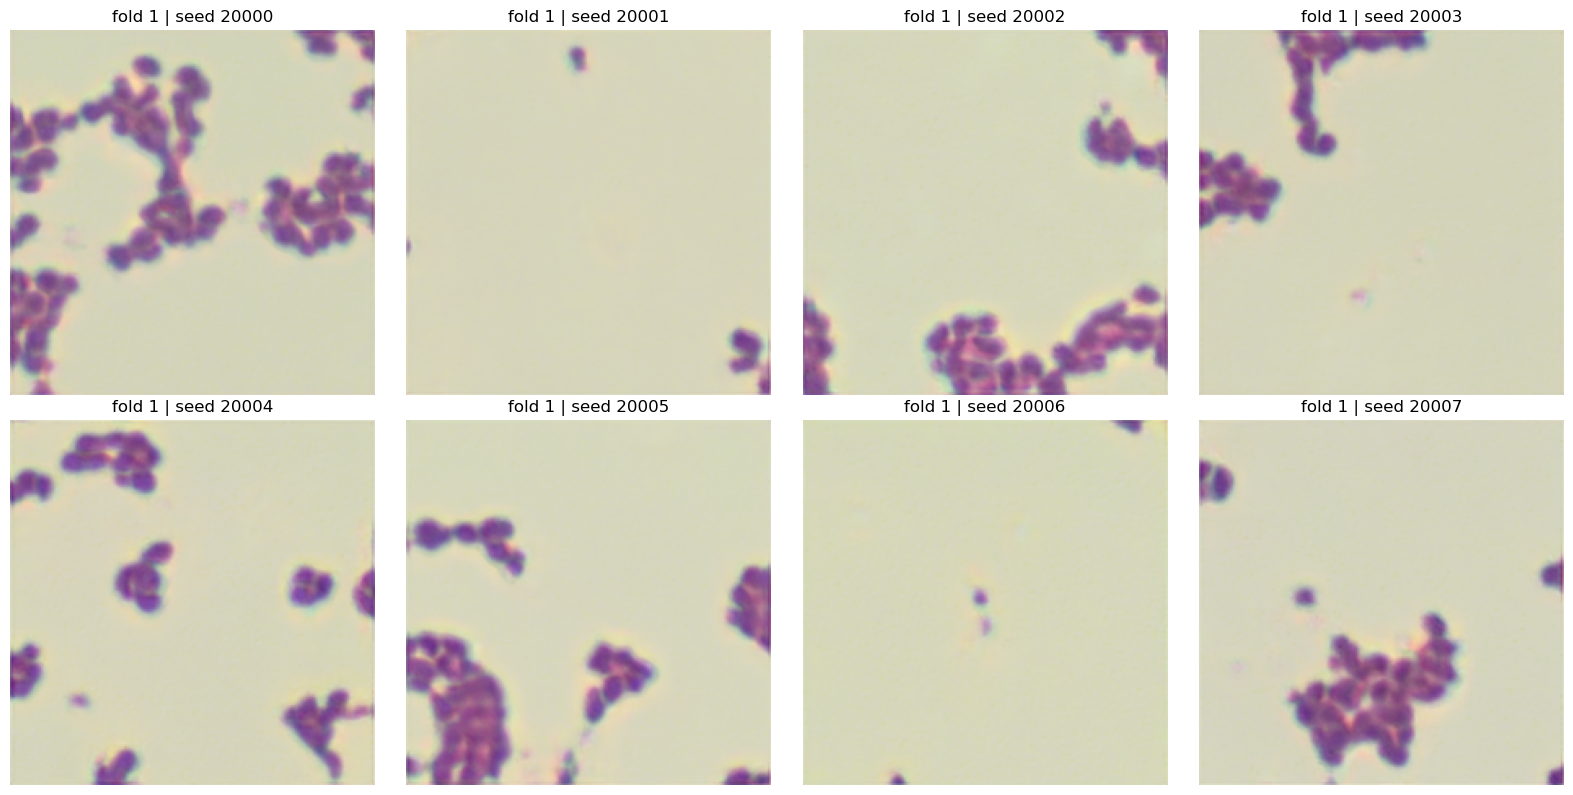

Saved generated 224 manifest to: C:\Users\FYP2610\Downloads\FYP2\manifests\gan_generated_manifest_224.csv


In [8]:
# We resize every generated image to the fixed 224x224 CNN input size.
generated_rows_224 = []
for row in generated_rows_256:
    fold_id = int(row["fold_id"])
    source_file = REPO_ROOT / row["file_path"]
    target_dir = GAN_IMAGES_224_DIR / f"fold_{fold_id}"
    target_dir.mkdir(parents=True, exist_ok=True)
    target_file = target_dir / source_file.name

    with Image.open(source_file) as image_handle:
        image = image_handle.convert("RGB")
        resized_image = image.resize((CNN_PATCH_SIZE, CNN_PATCH_SIZE), Image.Resampling.LANCZOS)
        resized_image.save(target_file)

    generated_rows_224.append({
        "dataset_name": row["dataset_name"],
        "gan_image_id": row["gan_image_id"].replace("_256", "_224"),
        "fold_id": row["fold_id"],
        "round_id": row["round_id"],
        "train_fold_id": row["train_fold_id"],
        "test_fold_ids": row["test_fold_ids"],
        "binary_label": row["binary_label"],
        "binary_group": row["binary_group"],
        "seed": row["seed"],
        "image_size": CNN_PATCH_SIZE,
        "file_path": as_repo_relative(REPO_ROOT, target_file),
        "source_file_256": row["file_path"],
        "snapshot_path": row["snapshot_path"],
        "source_type": row["source_type"],
    })

write_csv_rows(MANIFESTS_DIR / "gan_generated_manifest_224.csv", generated_rows_224, list(generated_rows_224[0].keys()))

summary = {
    "notebook_tag": NOTEBOOK_TAG,
    "seed": SEED,
    "gan_patch_size": GAN_PATCH_SIZE,
    "cnn_patch_size": CNN_PATCH_SIZE,
    "gan_batch_size": GAN_BATCH_SIZE,
    "gan_workers": GAN_WORKERS,
    "gan_kimg": GAN_KIMG,
    "gan_mirror": GAN_MIRROR,
    "snap_ticks": SNAP_TICKS,
    "ada_target": ADA_TARGET,
    "gan_cfg": GAN_CFG,
    "gan_aug": GAN_AUG,
    "gan_augpipe": GAN_AUGPIPE,
    "kid_metric_name": KID_METRIC_NAME,
    "generated_manifest_256": as_repo_relative(REPO_ROOT, MANIFESTS_DIR / "gan_generated_manifest_256.csv"),
    "generated_manifest_224": as_repo_relative(REPO_ROOT, MANIFESTS_DIR / "gan_generated_manifest_224.csv"),
}
write_json(NOTEBOOK_RESULTS_DIR / "summary.json", summary)

fold_result_rows = []
for fold_plan in fold_plan_rows:
    fold_id = int(fold_plan["train_fold_id"])
    generated_count = sum(1 for row in generated_rows_224 if int(row["fold_id"]) == fold_id)
    fold_result_rows.append({
        "fold_id": fold_id,
        "needed_gan_count_224": int(fold_plan["needed_gan_count_224"]),
        "generated_count_224": generated_count,
        "selected_snapshot_kimg": int(kid_lookup[fold_id]["snapshot_kimg"]),
        "selected_kid50k_full": kid_lookup[fold_id]["kid50k_full"],
    })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "gan_summary_by_fold.csv", fold_result_rows, list(fold_result_rows[0].keys()))
display(pd.DataFrame(fold_result_rows))
display(pd.DataFrame(generated_rows_224[:10]))

# This preview helps us audit that the resized synthetic patches look sensible.
preview_rows = generated_rows_224[:8]
if preview_rows:
    figure_columns = min(4, len(preview_rows))
    figure_rows = math.ceil(len(preview_rows) / figure_columns)
    fig, axes = plt.subplots(figure_rows, figure_columns, figsize=(4 * figure_columns, 4 * figure_rows))
    if not isinstance(axes, (list, tuple)):
        axes = [axes]
    flat_axes = []
    for item in axes:
        if isinstance(item, (list, tuple)):
            flat_axes.extend(item)
        else:
            try:
                flat_axes.extend(item.flatten().tolist())
            except AttributeError:
                flat_axes.append(item)
    for axis, row in zip(flat_axes, preview_rows):
        image_path = REPO_ROOT / row["file_path"]
        with Image.open(image_path) as image_handle:
            axis.imshow(image_handle.convert("RGB"))
        axis.set_title(f"fold {row['fold_id']} | seed {row['seed']}")
        axis.axis("off")
    for axis in flat_axes[len(preview_rows):]:
        axis.axis("off")
    fig.tight_layout()
    fig.savefig(NOTEBOOK_RESULTS_DIR / "generated_preview_224.png", dpi=200)
    plt.show()
print(f"Saved generated 224 manifest to: {MANIFESTS_DIR / 'gan_generated_manifest_224.csv'}")